# Auditoría inicial — Iranian Churn

Aquí comprobamos la calidad del archivo antes de separar datos o probar modelos. Este notebook cubre solo el paso 3. Conservamos el original y no elegimos variables por su relación con abandono.

Fuente: [UCI 563](https://archive.ics.uci.edu/dataset/563/iranian+churn+dataset), DOI 10.24432/C5JW3Z, licencia CC BY 4.0. Descarga: 2026-10-09. Según la ficha, las entradas resumen nueve meses y la etiqueta corresponde al mes doce; la fórmula de Customer Value y el criterio operativo de Status no están detallados.

Seguimos la carga y revisión de tablas de IA_ML_Example_Dif_Classifiers_CV y ML_Normalización, copiados sin cambios en referencia/.

Primero configuramos las rutas del proyecto nuevo.

In [1]:
EN_COLAB = False
if EN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    RUTA_BASE = '/content/drive/MyDrive/churn/'
else:
    RUTA_BASE = './'
RUTA_DATOS = RUTA_BASE + 'data/'
RUTA_MODELOS = RUTA_BASE + 'models/'
RUTA_RESULTADOS = RUTA_BASE + 'resultados/'
RUTA_FIGURAS = RUTA_BASE + 'figuras/'

Cargamos las herramientas de auditoría. En local verificamos que el kernel sea el entorno propio de churn; no necesitamos librerías nuevas.

In [2]:
import sys
import json
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if not EN_COLAB:
    assert Path(sys.prefix).resolve() == (Path(RUTA_BASE) / '.venv').resolve(), 'Seleccionar el kernel de churn/.venv.'
Path(RUTA_RESULTADOS).mkdir(exist_ok=True)
Path(RUTA_FIGURAS).mkdir(exist_ok=True)
print('Python:', sys.version.split()[0])

Python: 3.11.9


Leemos el CSV sin cambiar sus nombres, registros ni orden. El hash comprueba que sigue siendo el archivo descargado; no demuestra por sí mismo la veracidad de sus observaciones.

In [3]:
ruta_original = Path(RUTA_DATOS) / 'original' / 'Customer Churn.csv'
sha_csv = hashlib.sha256(ruta_original.read_bytes()).hexdigest()
assert sha_csv == '90d5fb6bd1630cd4de4b4d28fcf8b4cb92a8f6ab7484605b0799d47386f7dbe1'
datos = pd.read_csv(ruta_original)
columnas_esperadas = ['Call  Failure', 'Complains', 'Subscription  Length', 'Charge  Amount',
                     'Seconds of Use', 'Frequency of use', 'Frequency of SMS', 'Distinct Called Numbers',
                     'Age Group', 'Tariff Plan', 'Status', 'Age', 'Customer Value', 'Churn']
assert datos.shape == (3150, 14), 'Revisar dimensiones antes de continuar.'
assert list(datos.columns) == columnas_esperadas, 'El esquema cambió.'
print('Filas y columnas:', datos.shape)
print('SHA256:', sha_csv)
datos.info()

Filas y columnas: (3150, 14)
SHA256: 90d5fb6bd1630cd4de4b4d28fcf8b4cb92a8f6ab7484605b0799d47386f7dbe1
<class 'pandas.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Call  Failure            3150 non-null   int64  
 1   Complains                3150 non-null   int64  
 2   Subscription  Length     3150 non-null   int64  
 3   Charge  Amount           3150 non-null   int64  
 4   Seconds of Use           3150 non-null   int64  
 5   Frequency of use         3150 non-null   int64  
 6   Frequency of SMS         3150 non-null   int64  
 7   Distinct Called Numbers  3150 non-null   int64  
 8   Age Group                3150 non-null   int64  
 9   Tariff Plan              3150 non-null   int64  
 10  Status                   3150 non-null   int64  
 11  Age                      3150 non-null   int64  
 12  Customer Value           3150 non-null   

La ficha indica 13 entradas, aunque un párrafo menciona 13 columnas. El archivo descargado trae 14 contando Churn: no eliminamos una columna para ajustarlo al párrafo. Hay nombres con espacios dobles que documentamos y dejamos intactos.

Revisamos tipos, nulos, valores no finitos, mínimos, máximos y columnas constantes. Esta revisión es de integridad; todavía no hacemos correlaciones ni seleccionamos rasgos.

In [4]:
def resumir_columnas(df):
    """Recibe una tabla y devuelve tipos, faltantes, rango y variedad de cada columna sin modificarla."""
    rows = []
    for columna in df.columns:
        serie = df[columna]
        rows.append({'Columna': columna, 'Tipo': str(serie.dtype),
                     'Nulos': int(serie.isna().sum()),
                     'No_finitos': int((~np.isfinite(serie)).sum()),
                     'Valores_distintos': int(serie.nunique()),
                     'Minimo': float(serie.min()), 'Maximo': float(serie.max())})
    return pd.DataFrame(rows)

tabla_columnas = resumir_columnas(datos)
tabla_columnas.to_csv(RUTA_RESULTADOS + 'auditoria_columnas.csv', index=False)
display(tabla_columnas)

,Columna,Tipo,Nulos,No_finitos,Valores_distintos,Minimo,Maximo
0,Call Failure,int64,0,0,37,0.0,36.00
1,Complains,int64,0,0,2,0.0,1.00
2,Subscription Length,int64,0,0,45,3.0,47.00
3,Charge Amount,int64,0,0,11,0.0,10.00
4,Seconds of Use,int64,0,0,1756,0.0,17090.00
5,Frequency of use,int64,0,0,242,0.0,255.00
6,Frequency of SMS,int64,0,0,405,0.0,522.00
7,Distinct Called Numbers,int64,0,0,92,0.0,97.00
8,Age Group,int64,0,0,5,1.0,5.00
9,Tariff Plan,int64,0,0,2,1.0,2.00


**Lo que notamos.** Ninguna de las 14 columnas tiene nulos ni valores no finitos; tampoco hay columnas constantes. Age tiene solo cinco valores distintos: no asumimos que sean edades individuales exactas.

Comprobamos los dominios documentados. Si aparece un valor fuera de la descripción lo reportamos; no lo recodificamos ni borramos sin decidirlo con el equipo.

In [5]:
dominios = {'Complains': [0, 1], 'Age Group': [1, 2, 3, 4, 5],
            'Tariff Plan': [1, 2], 'Status': [1, 2], 'Churn': [0, 1]}
rows = []
for columna, permitidos in dominios.items():
    fuera = ~datos[columna].isin(permitidos)
    rows.append({'Regla': columna + ': dominio documentado', 'Filas_fuera': int(fuera.sum())})
fuera_cargo = ~datos['Charge  Amount'].between(0, 9)
rows.append({'Regla': 'Charge Amount: rango documentado 0 a 9', 'Filas_fuera': int(fuera_cargo.sum())})
negativos = (datos < 0).any(axis=1)
rows.append({'Regla': 'Entradas y etiqueta no negativas', 'Filas_fuera': int(negativos.sum())})
tabla_calidad = pd.DataFrame(rows)
tabla_calidad.to_csv(RUTA_RESULTADOS + 'auditoria_dominios.csv', index=False)
display(tabla_calidad)
print('Valores observados de Charge Amount:', sorted(datos['Charge  Amount'].unique().tolist()))
print('Valores observados de Age:', sorted(datos['Age'].unique().tolist()))
print('Relación entre Age y Age Group:')
display(datos[['Age', 'Age Group']].drop_duplicates().sort_values(['Age', 'Age Group']))

,Regla,Filas_fuera
0,Complains: dominio documentado,0
1,Age Group: dominio documentado,0
2,Tariff Plan: dominio documentado,0
3,Status: dominio documentado,0
4,Churn: dominio documentado,0
5,Charge Amount: rango documentado 0 a 9,7
6,Entradas y etiqueta no negativas,0


Valores observados de Charge Amount: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Valores observados de Age: [15, 25, 30, 45, 55]
Relación entre Age y Age Group:


,Age,Age Group
3,15,1
1,25,2
0,30,3
20,45,4
23,55,5


**Lo que notamos.** Los dominios binarios y Age Group coinciden con la ficha. Charge Amount tiene siete filas con valor 10, fuera del rango documentado 0 a 9. Conservamos esos registros y dejamos pendiente su tratamiento; no los recortamos ni inventamos otro valor.

Contamos las clases para dimensionar el desbalance. Este conteo global es una comprobación previa a la reserva; no se usa para escoger modelos ni umbrales.

,Clase,Cantidad,Porcentaje
0,0,2655,84.285714
1,1,495,15.714286


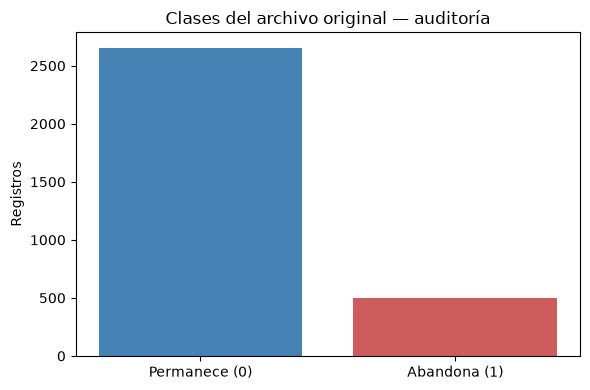

In [6]:
conteo = datos['Churn'].value_counts().sort_index()
tabla_clases = pd.DataFrame({'Clase': conteo.index, 'Cantidad': conteo.values,
                            'Porcentaje': conteo.values / len(datos) * 100})
tabla_clases.to_csv(RUTA_RESULTADOS + 'auditoria_clases.csv', index=False)
display(tabla_clases)
plt.figure(figsize=(6, 4))
plt.bar(['Permanece (0)', 'Abandona (1)'], conteo.values, color=['steelblue', 'indianred'])
plt.ylabel('Registros')
plt.title('Clases del archivo original — auditoría')
plt.tight_layout()
plt.savefig(RUTA_FIGURAS + '00_distribucion_clase_auditoria.png', dpi=150, bbox_inches='tight')
plt.show()

**Lo que notamos.** Hay 495 abandonos (15,71 %) y 2.655 permanencias (84,29 %). Acertar siempre la clase mayoritaria no demuestra capacidad para anticipar abandono.

Una repetición de fila no prueba que sea un cliente duplicado: no hay ID de cliente en este CSV. Distinguimos repeticiones completas de perfiles de entrada idénticos. Contamos también perfiles con etiquetas contradictorias, sin usar la etiqueta para definir el perfil.

In [7]:
rasgos_originales = datos.columns.drop('Churn').tolist()
perfiles = datos.groupby(rasgos_originales, dropna=False, sort=False)['Churn'].agg(['size', 'nunique'])
repetidos = perfiles['size'] > 1
contradictorios = perfiles['nunique'] > 1
auditoria = {
    'filas': int(len(datos)),
    'entradas': int(len(rasgos_originales)),
    'abandono': int((datos['Churn'] == 1).sum()),
    'permanencia': int((datos['Churn'] == 0).sum()),
    'nulos': int(datos.isna().sum().sum()),
    'no_finitos': int((~np.isfinite(datos)).sum().sum()),
    'repeticiones_exactas_adicionales': int(datos.duplicated().sum()),
    'filas_participantes_repeticion_exacta': int(datos.duplicated(keep=False).sum()),
    'perfiles_unicos_13_entradas': int(len(perfiles)),
    'grupos_perfil_repetido': int(repetidos.sum()),
    'filas_en_perfiles_repetidos': int(perfiles.loc[repetidos, 'size'].sum()),
    'tamano_maximo_perfil': int(perfiles['size'].max()),
    'perfiles_con_etiquetas_distintas': int(contradictorios.sum()),
    'filas_en_perfiles_con_etiquetas_distintas': int(perfiles.loc[contradictorios, 'size'].sum()),
    'charge_amount_fuera_0_9': int(fuera_cargo.sum())
}
print(json.dumps(auditoria, indent=2, ensure_ascii=False))
assert len(perfiles) == len(datos.drop_duplicates(subset=rasgos_originales))
with open(RUTA_RESULTADOS + 'auditoria_resumen.json', 'w', encoding='utf-8') as archivo:
    json.dump(auditoria, archivo, ensure_ascii=False, indent=2)

{
  "filas": 3150,
  "entradas": 13,
  "abandono": 495,
  "permanencia": 2655,
  "nulos": 0,
  "no_finitos": 0,
  "repeticiones_exactas_adicionales": 300,
  "filas_participantes_repeticion_exacta": 465,
  "perfiles_unicos_13_entradas": 2836,
  "grupos_perfil_repetido": 162,
  "filas_en_perfiles_repetidos": 476,
  "tamano_maximo_perfil": 11,
  "perfiles_con_etiquetas_distintas": 14,
  "filas_en_perfiles_con_etiquetas_distintas": 64,
  "charge_amount_fuera_0_9": 7
}


**Lo que notamos.** Hay 300 repeticiones adicionales de filas completas; 465 filas participan en esas repeticiones. Sobre las 13 entradas hay 2.836 perfiles distintos: 162 grupos repetidos contienen 476 filas, con un grupo de hasta 11 registros. Catorce perfiles presentan etiquetas diferentes (64 filas). Mantenemos las etiquetas originales y agruparemos sin usar Churn; no suponemos que un mismo perfil garantice el mismo resultado.

Registramos las fuentes y las incertidumbres por variable. Status significa activo/no activo, pero falta su criterio operativo; Customer Value es un valor calculado sin fórmula ni unidad publicadas en la ficha consultada. Eso exige revisión, no demuestra filtración. No calculamos su asociación con Churn antes de reservar test.

In [8]:
diccionario = [
    ('Call  Failure', 'Conteo', 'Llamadas fallidas', 'Nombre con espacios dobles.'),
    ('Complains', 'Binaria', '0 sin queja; 1 con queja', 'No es el número de quejas.'),
    ('Subscription  Length', 'Numérica', 'Meses de suscripción', 'Nombre con espacios dobles.'),
    ('Charge  Amount', 'Ordinal', 'Nivel de cargo, documentado de 0 a 9', 'Revisar valores 10; no asumir unidades monetarias.'),
    ('Seconds of Use', 'Numérica', 'Segundos de llamadas', 'Medición agregada.'),
    ('Frequency of use', 'Conteo', 'Número de llamadas', 'Medición agregada.'),
    ('Frequency of SMS', 'Conteo', 'Número de mensajes', 'Medición agregada.'),
    ('Distinct Called Numbers', 'Conteo', 'Números distintos llamados', 'Medición agregada.'),
    ('Age Group', 'Ordinal', 'Grupo de edad de 1 a 5', 'Revisar redundancia con Age.'),
    ('Tariff Plan', 'Nominal binaria', '1 pago por uso; 2 contractual', 'Los códigos no son cantidades.'),
    ('Status', 'Nominal binaria', '1 activo; 2 no activo', 'Aclarar criterio de inactividad y momento operativo.'),
    ('Age', 'Numérica', 'Edad', 'Pocos valores distintos: posible discretización; no afirmar edades exactas.'),
    ('Customer Value', 'Numérica derivada', 'Valor calculado del cliente', 'Fórmula, unidad y trazabilidad no detalladas.'),
    ('Churn', 'Objetivo binario', '1 abandono; 0 permanencia', 'Mes doce según UCI; nunca entra como rasgo.')
]
tabla_diccionario = pd.DataFrame(diccionario, columns=['Columna', 'Tratamiento_provisional', 'Descripcion', 'Observacion'])
tabla_diccionario.to_csv(RUTA_RESULTADOS + 'diccionario_datos.csv', index=False)
display(tabla_diccionario)
procedencia = {
    'dataset': 'Iranian Churn', 'uci_id': 563,
    'pagina': 'https://archive.ics.uci.edu/dataset/563/iranian+churn+dataset',
    'descarga': 'https://archive.ics.uci.edu/static/public/563/iranian+churn+dataset.zip',
    'doi': '10.24432/C5JW3Z', 'licencia': 'CC BY 4.0', 'fecha_descarga': '2026-10-09',
    'csv': 'data/original/Customer Churn.csv', 'sha256_csv': sha_csv,
    'sha256_zip': hashlib.sha256((Path(RUTA_DATOS) / 'iranian_churn_uci.zip').read_bytes()).hexdigest(),
    'original_modificado': False,
    'nota': 'Entradas de meses 1 a 9 y etiqueta al mes 12 según ficha UCI; sin fechas individuales ni ID en el CSV.'
}
with open(RUTA_DATOS + 'procedencia.json', 'w', encoding='utf-8') as archivo:
    json.dump(procedencia, archivo, ensure_ascii=False, indent=2)
assert hashlib.sha256(ruta_original.read_bytes()).hexdigest() == sha_csv
assert not (Path(RUTA_DATOS) / 'train.csv').exists()
assert not (Path(RUTA_DATOS) / 'test.csv').exists()
print('Original intacto; todavía no se crearon particiones ni se entrenaron modelos.')

,Columna,Tratamiento_provisional,Descripcion,Observacion
0,Call Failure,Conteo,Llamadas fallidas,Nombre con espacios dobles.
1,Complains,Binaria,0 sin queja; 1 con queja,No es el número de quejas.
2,Subscription Length,Numérica,Meses de suscripción,Nombre con espacios dobles.
3,Charge Amount,Ordinal,"Nivel de cargo, documentado de 0 a 9",Revisar valores 10; no asumir unidades monetar...
4,Seconds of Use,Numérica,Segundos de llamadas,Medición agregada.
5,Frequency of use,Conteo,Número de llamadas,Medición agregada.
6,Frequency of SMS,Conteo,Número de mensajes,Medición agregada.
7,Distinct Called Numbers,Conteo,Números distintos llamados,Medición agregada.
8,Age Group,Ordinal,Grupo de edad de 1 a 5,Revisar redundancia con Age.
9,Tariff Plan,Nominal binaria,1 pago por uso; 2 contractual,Los códigos no son cantidades.


Original intacto; todavía no se crearon particiones ni se entrenaron modelos.


## Conclusiones de la auditoría

Los resultados numéricos quedan guardados en resultados/auditoria_resumen.json y las tablas de auditoría. Conservamos todas las filas y variables originales. El criterio preciso de agrupación y el uso de Status, Customer Value y los códigos fuera de documentación se resolverán antes de la partición, en el paso 4. La auditoría no prueba rendimiento ni utilidad comercial.